In [40]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from importlib import reload
import matplotlib.pyplot as plt
import seaborn as sns
import data_processing

In [2]:
h2o_data = xr.open_dataset('ACEFTS_L2_v5p2_H2O.nc')
h2o_flags = xr.open_dataset('ACEFTS_L2_v5p2_flags_H2O.nc')

In [3]:
h2o_data = h2o_data.set_index(index=['orbit', 'sunset_sunrise'])
h2o_flags = h2o_flags.set_index(index=['orbit', 'sunset_sunrise'])

In [38]:
def encode_time_features(year, month, day, hour):
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    day_sin = np.sin(2 * np.pi * day / 31)
    day_cos = np.cos(2 * np.pi * day / 31)
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    year_normalized = (year - 2004) / (20)
    return [year_normalized, month_sin, month_cos, day_sin, day_cos, hour_sin, hour_cos]

In [41]:
reload(data_processing)
import data_processing
from data_processing import preprocess_profile_data as ppd

In [42]:
date_indices = np.arange(len(h2o_data['year'].values))

In [45]:
features, labels, feature_date_indices = ppd('H2O', 
                                             h2o_data, 
                                             h2o_flags, 
                                             date_indices, 
                                             n_surrounding = 4, 
                                             n_altitudes = len(h2o_data['altitude'].values),
                                             filter_indices = True
                                             )

VMR for date index 256 is empty after screening
VMR for date index 1753 is empty after screening
VMR for date index 2319 is empty after screening
VMR for date index 2506 is empty after screening
VMR for date index 4293 is empty after screening
VMR for date index 4316 is empty after screening
VMR for date index 4591 is empty after screening
VMR for date index 4683 is empty after screening
VMR for date index 4695 is empty after screening
VMR for date index 4773 is empty after screening
VMR for date index 5448 is empty after screening
VMR for date index 5617 is empty after screening
VMR for date index 5743 is empty after screening
VMR for date index 6082 is empty after screening
VMR for date index 6844 is empty after screening
VMR for date index 7916 is empty after screening
VMR for date index 7917 is empty after screening
VMR for date index 7977 is empty after screening
VMR for date index 7989 is empty after screening
VMR for date index 8142 is empty after screening
VMR for date index 83

In [46]:
features.shape

(125194, 5, 150, 11)

In [62]:
labels.shape
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(124340), np.int64(1): np.int64(854)}


In [48]:
import tensorflow as tf

In [49]:
from keras import layers, models

In [63]:
from keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4)  # Lower the learning rate

In [64]:
import tensorflow as tf

def binary_accuracy_with_threshold(y_true, y_pred):
    """
    Custom accuracy metric for binary classification with a threshold.
    """
    y_pred_discrete = tf.cast(y_pred > 0.5, tf.float32)
    return tf.keras.metrics.binary_accuracy(y_true, y_pred_discrete)

In [65]:
# Define the CNN-LSTM model
def build_cnn_lstm_model(n_profiles, n_altitudes, n_features):
    """
    Builds a CNN-LSTM model for profile classification.

    Parameters:
    - n_profiles: Number of profiles per sample.
    - n_altitudes: Number of altitude levels per profile.
    - n_features: Number of features per altitude.

    Returns:
    - model: Compiled CNN-LSTM model.
    """
    input_shape = (n_profiles, n_altitudes, n_features)

    # Input layer
    inputs = tf.keras.Input(shape=input_shape)

    # Time-distributed CNN layers
    cnn = layers.TimeDistributed(
        models.Sequential([
            layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_altitudes, n_features)),
            layers.MaxPooling1D(pool_size=2),
            layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
            layers.MaxPooling1D(pool_size=2),
            layers.Flatten()
        ])
    )(inputs)

    # LSTM layers
    lstm = layers.LSTM(128, return_sequences=False)(cnn)

    # Fully connected layers
    dense = layers.Dense(64, activation='relu')(lstm)
    outputs = layers.Dense(1, activation='sigmoid')(dense)  # Binary classification

    # Build the model
    model = models.Model(inputs=inputs, outputs=outputs)

    # Compile the model
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[binary_accuracy_with_threshold])

    return model


In [66]:
n_profiles = 5
n_altitudes = len(h2o_data['altitude'].values)
n_features = 11

model = build_cnn_lstm_model(n_profiles, n_altitudes, n_features)

/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
from keras._tf_keras.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [68]:
# Split the data into training, validation, and test sets
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [35]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [140]:
import numpy as np

# Compute raw class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Apply logarithmic scaling
smoothed_weights = np.log1p(class_weights)

# Convert to dictionary for Keras
class_weights_dict = {i: smoothed_weights[i] for i in range(len(smoothed_weights))}

In [141]:
intermediate_weights = (class_weights + smoothed_weights)/2

class_weights_dict = {i: intermediate_weights[i] for i in range(len(intermediate_weights))}

Epoch 1/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 117s 42ms/step - binary_accuracy_with_threshold: 0.9895 - loss: 0.2965 - val_binary_accuracy_with_threshold: 0.9930 - val_loss: 0.1982
Epoch 2/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 114s 42ms/step - binary_accuracy_with_threshold: 0.9935 - loss: 0.2644 - val_binary_accuracy_with_threshold: 0.9930 - val_loss: 0.1746
Epoch 3/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 120s 44ms/step - binary_accuracy_with_threshold: 0.9927 - loss: 0.2759 - val_binary_accuracy_with_threshold: 0.9930 - val_loss: 0.1330
Epoch 4/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 124s 45ms/step - binary_accuracy_with_threshold: 0.9866 - loss: 0.2474 - val_binary_accuracy_with_threshold: 0.9912 - val_loss: 0.1009
Epoch 5/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 123s 45ms/step - binary_accuracy_with_threshold: 0.9789 - loss: 0.2233 - val_binary_accuracy_with_threshold: 0.9146 - val_loss: 0.3134
Epoch 6/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 135s 49ms/step - binary_accuracy_with_threshold: 0.9711 - loss: 0.2148 - 

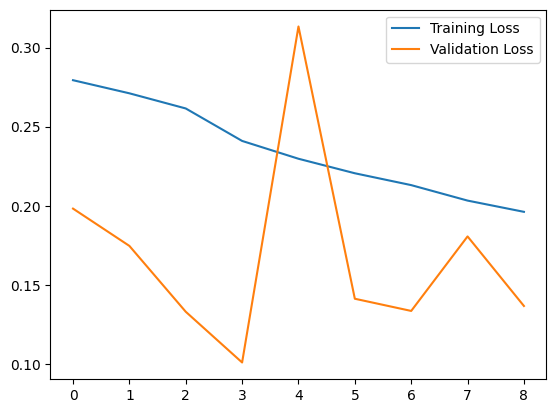

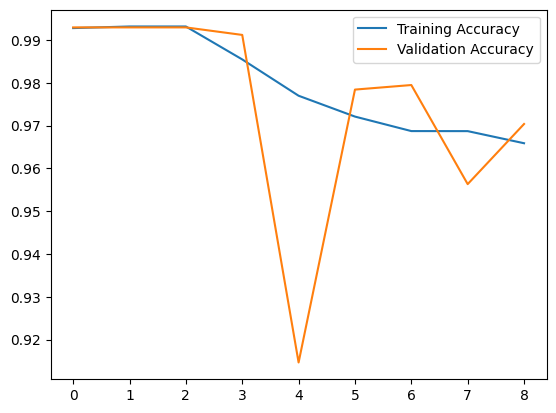

In [69]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weight_dict
)

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['binary_accuracy_with_threshold'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy_with_threshold'], label='Validation Accuracy')
plt.legend()
plt.show()

587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     18655
           1       0.16      0.07      0.10       125

    accuracy                           0.99     18780
   macro avg       0.58      0.53      0.55     18780
weighted avg       0.99      0.99      0.99     18780



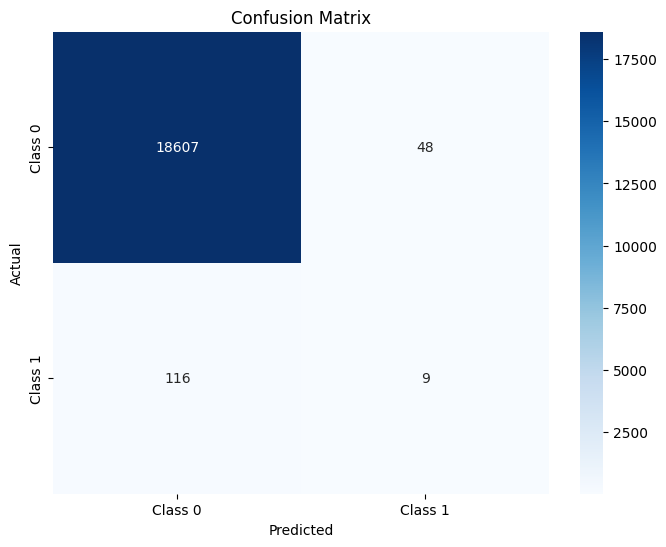

In [70]:
# Get predictions
predictions = model.predict(X_test)

# Convert probabilities to discrete labels
discrete_predictions = (predictions > 0.5).astype(int)

# Print classification report
print(classification_report(y_test, discrete_predictions))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, discrete_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

587/587 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - binary_accuracy_with_threshold: 0.7806 - loss: 0.4861
Test Loss: 0.48358792066574097, Test Accuracy: 0.7832268476486206


In [25]:
years = h2o_data['year'].values
months = h2o_data['month'].values
days = h2o_data['day'].values
hours = h2o_data['hour'].values
times = pd.to_datetime({
    'year': years,
    'month': months,
    'day': days,
    'hour': hours
})

In [26]:
bad_profile_indices = []
for i in range(0, len(times)-1):
    orbit_number = h2o_data['orbit'][i].values
    ss = h2o_data['sunset_sunrise'][i].values

    try:
        flag_profile = h2o_flags['quality_flag'].sel(orbit=orbit_number, sunset_sunrise=ss).values
        if ((flag_profile != 0) & (flag_profile != 8) & (flag_profile != 9)).any():
            bad_profile_indices.append(i)
    except KeyError:
        print(f"Skipping missing orbit/sunset_sunrise pair: orbit={orbit_number}, sunset_sunrise={ss}")
        continue

Skipping missing orbit/sunset_sunrise pair: orbit=110807.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=110955.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111363.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111430.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111444.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111445.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111466.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112226.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112505.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112518.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112525.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112526.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=11

In [27]:
bad_features, bad_labels = ppd('H2O', h2o_data, h2o_flags, bad_profile_indices, n_surrounding = 2, n_altitudes = len(h2o_data['altitude'].values))

Skipping due to instrumental error: orbit=29089.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29143.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29147.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29175.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29178.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29179.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29195.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29219.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29263.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29267.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29268.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29294.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29296.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29304.0, sunset_sunrise=1.0
Skipping due to inst

In [28]:
test_loss, test_accuracy = model.evaluate(bad_features, bad_labels)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy_with_threshold: 0.8448 - loss: 0.3934
Test Loss: 0.37135571241378784, Test Accuracy: 0.8633663654327393


In [71]:
from data_processing import vertical_profile_plot as vpp

UnboundLocalError: local variable 'current_occultation' referenced before assignment

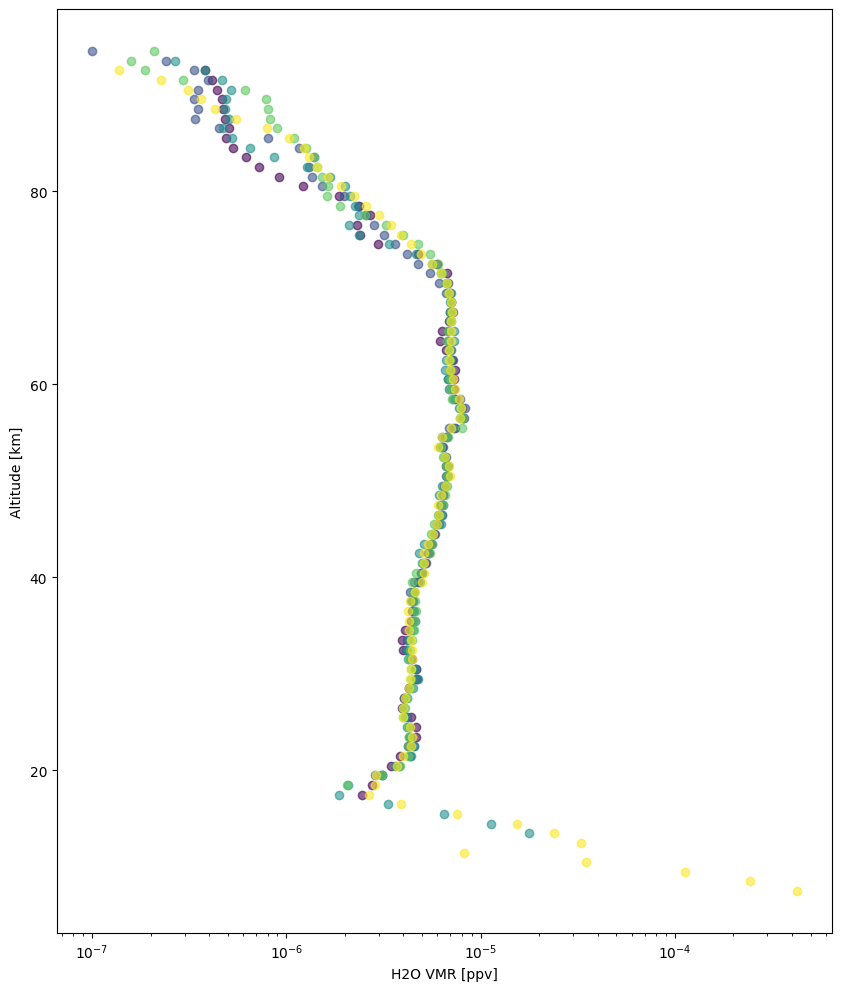

In [72]:
date_indices_example = feature_date_indices[0]

vpp('H2O', h2o_data, h2o_flags, date_indices_example)